# Experiment 7: End-to-End Study of Autoencoders and Their Variants

 ## Introduction

 Autoencoders are neural networks designed to learn efficient representations of data by reconstructing an input from a compressed latent representation. They consist of two main components: an **encoder**, which maps the input to a lower-dimensional latent space, and a **decoder**, which reconstructs the original input from this representation. By learning to minimize reconstruction error, autoencoders can capture important patterns and features present in the data.

 In this experiment, the **MNIST handwritten digit dataset** is used to develop and study different types of autoencoders. The experiment begins with a **Fully Connected Autoencoder**, where each $28 \times 28$ grayscale image is flattened into a 784-dimensional vector. A **Convolutional Autoencoder (CAE)** is then implemented to preserve the spatial structure of images through convolution and pooling operations.

 Next, a **Denoising Autoencoder** is developed by introducing controlled corruption, such as Gaussian and salt-and-pepper noise, into the input images. The model is trained to reconstruct the original clean images, demonstrating the ability of neural networks to learn robust image representations.

 Finally, a **Variational Autoencoder (VAE)** is implemented. Unlike conventional autoencoders that learn deterministic latent vectors, a VAE learns a probability distribution in the latent space using the mean and variance produced by the encoder. The reparameterization trick enables sampling from this distribution while maintaining differentiability. The VAE is further explored through latent-space visualization, random image generation, and latent-space interpolation.

 The models are evaluated quantitatively using **Mean Squared Error (MSE), Mean Absolute Error (MAE), and Structural Similarity Index (SSIM)**, along with qualitative visualization of reconstructed and generated images. Training and validation losses, reconstruction-error distributions, and high-error samples are also analyzed.

 Overall, this experiment provides an end-to-end understanding of **image representation, reconstruction, denoising, dimensionality reduction, and generative modeling**, while highlighting the differences between deterministic and probabilistic latent representations.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import mean_squared_error, mean_absolute_error
from skimage.metrics import structural_similarity as ssim

In [3]:
(x_train_full, _), (x_test_full, _) = mnist.load_data()

print("Full train shape:", x_train_full.shape)
print("Full test shape :", x_test_full.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Full train shape: (60000, 28, 28)
Full test shape : (10000, 28, 28)


In [4]:
x_train_full = x_train_full.astype('float32') / 255.0
x_test_full  = x_test_full.astype('float32') / 255.0

In [5]:
# 10,000 training images + 2,000 test images
x_train = x_train_full[:10000]
x_test  = x_test_full[:2000]

print("Lab train shape:", x_train.shape)
print("Lab test shape :", x_test.shape)

Lab train shape: (10000, 28, 28)
Lab test shape : (2000, 28, 28)


In [6]:
x_train = np.expand_dims(x_train, axis=-1)   # (10000, 28, 28, 1)
x_test  = np.expand_dims(x_test, axis=-1)    # (2000, 28, 28, 1)

print("Spatial train shape:", x_train.shape)
print("Spatial test shape :", x_test.shape)

Spatial train shape: (10000, 28, 28, 1)
Spatial test shape : (2000, 28, 28, 1)


In [7]:
x_train_flat = x_train.reshape((len(x_train), 784))
x_test_flat  = x_test.reshape((len(x_test), 784))

print("Flat train shape:", x_train_flat.shape)
print("Flat test shape :", x_test_flat.shape)

Flat train shape: (10000, 784)
Flat test shape : (2000, 784)


In [8]:
print("Pixel range train :", x_train.min(), "→", x_train.max())
print("Pixel range test  :", x_test.min(), "→", x_test.max())
print("Train samples     :", len(x_train))
print("Test samples      :", len(x_test))

Pixel range train : 0.0 → 1.0
Pixel range test  : 0.0 → 1.0
Train samples     : 10000
Test samples      : 2000


In [9]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

input_dim = 784
latent_dim = 16

inp = Input(shape=(input_dim,))
x = Dense(128, activation='relu')(inp)
x = Dense(32, activation='relu')(x)
latent = Dense(latent_dim, activation='relu', name='latent')(x)
x = Dense(32, activation='relu')(latent)
x = Dense(128, activation='relu')(x)
out = Dense(input_dim, activation='sigmoid')(x)

fc_ae = Model(inp, out, name='FC_Autoencoder')
fc_ae.summary()

Model: "FC_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,040 (824.38 KB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
from tensorflow.keras.optimizers import Adam

fc_ae.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy'
)

In [11]:
history_fc = fc_ae.fit(
    x_train_flat, x_train_flat,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    shuffle=True,
    verbose=1
)

Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.3563 - val_loss: 0.2564
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2358 - val_loss: 0.2193
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2030 - val_loss: 0.1943
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1811 - val_loss: 0.1787
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1691 - val_loss: 0.1684
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1597 - val_loss: 0.1603
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1531 - val_loss: 0.1554
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1477 - val_loss: 0.1518
Epoch 9/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1433 - val_loss: 0.1476
Epoch 10/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1403 - val_loss: 0.1455
Epoch 11/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1382 - val_loss: 0.1434
Epoch 12/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1366 - val_

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


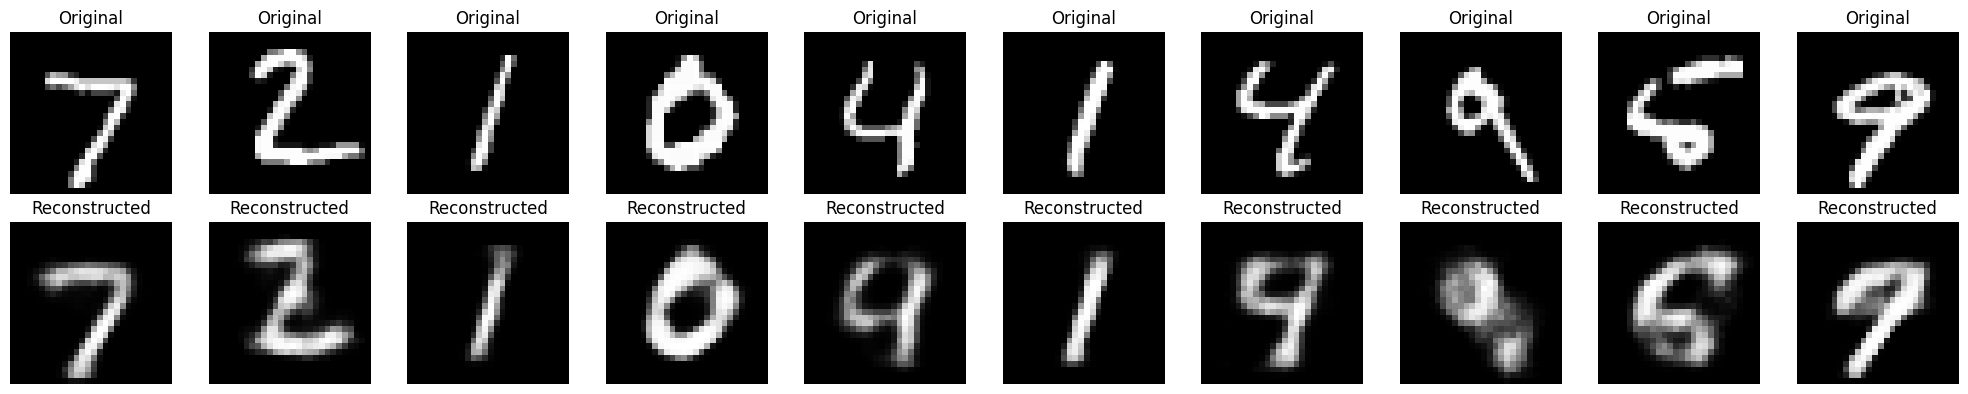

In [12]:
import matplotlib.pyplot as plt
import numpy as np

n = 10
decoded = fc_ae.predict(x_test_flat[:n])

plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_flat[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')
    
    # Reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')
plt.tight_layout()
plt.show()

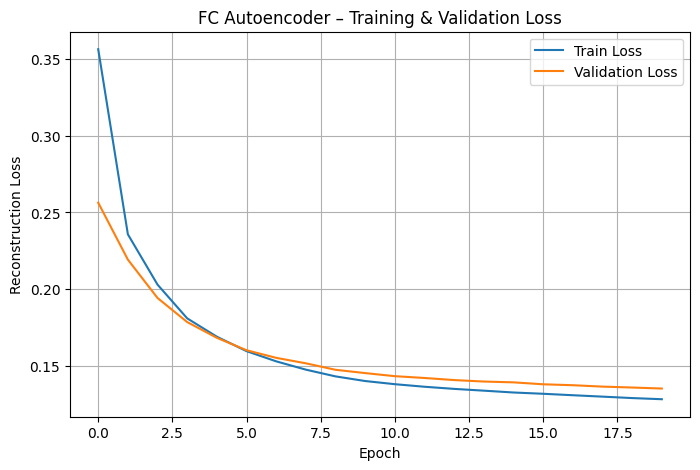

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(history_fc.history['loss'], label='Train Loss')
plt.plot(history_fc.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Reconstruction Loss')
plt.title('FC Autoencoder – Training & Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
from skimage.metrics import structural_similarity as ssim
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Predict on full test set
recon_fc = fc_ae.predict(x_test_flat)

# MSE & MAE (pixel-wise)
mse_fc = mean_squared_error(x_test_flat, recon_fc)
mae_fc = mean_absolute_error(x_test_flat, recon_fc)

# Mean SSIM
ssim_scores = [
    ssim(x_test_flat[i].reshape(28, 28), recon_fc[i].reshape(28, 28), data_range=1.0)
    for i in range(len(x_test_flat))
]
mean_ssim_fc = np.mean(ssim_scores)

print(f"Test MSE  : {mse_fc:.6f}")
print(f"Test MAE  : {mae_fc:.6f}")
print(f"Mean SSIM : {mean_ssim_fc:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test MSE  : 0.023641
Test MAE  : 0.061607
Mean SSIM : 0.7201


In [15]:
def build_fc_ae(latent_dim):
    inp = Input(shape=(784,))
    x = Dense(128, activation='relu')(inp)
    x = Dense(32, activation='relu')(x)
    latent = Dense(latent_dim, activation='relu')(x)
    x = Dense(32, activation='relu')(latent)
    x = Dense(128, activation='relu')(x)
    out = Dense(784, activation='sigmoid')(x)
    model = Model(inp, out)
    model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy')
    return model

latent_dims = [2, 8, 16, 32]
results_latent = {}

for dz in latent_dims:
    print(f"\n=== Training FC-AE with latent dim = {dz} ===")
    model = build_fc_ae(dz)
    model.fit(x_train_flat, x_train_flat, epochs=15, batch_size=128,
              validation_split=0.1, verbose=0)
    
    recon = model.predict(x_test_flat)
    mse = mean_squared_error(x_test_flat, recon)
    ssim_val = np.mean([
        ssim(x_test_flat[i].reshape(28,28), recon[i].reshape(28,28), data_range=1.0)
        for i in range(len(x_test_flat))
    ])
    params = model.count_params()
    
    results_latent[dz] = {'MSE': mse, 'SSIM': ssim_val, 'Params': params}
    print(f"MSE: {mse:.6f} | SSIM: {ssim_val:.4f} | Params: {params}")


=== Training FC-AE with latent dim = 2 ===
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MSE: 0.050217 | SSIM: 0.4009 | Params: 210130

=== Training FC-AE with latent dim = 8 ===
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MSE: 0.035147 | SSIM: 0.5952 | Params: 210520

=== Training FC-AE with latent dim = 16 ===
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MSE: 0.026629 | SSIM: 0.6822 | Params: 211040

=== Training FC-AE with latent dim = 32 ===
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MSE: 0.023385 | SSIM: 0.7187 | Params: 212080


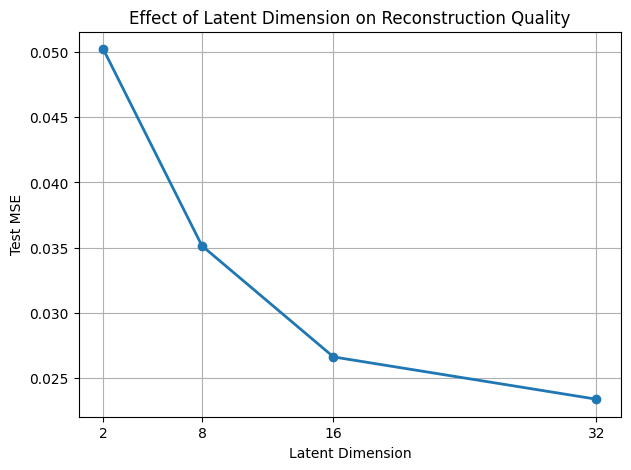

In [16]:
dims = list(results_latent.keys())
mses = [results_latent[d]['MSE'] for d in dims]

plt.figure(figsize=(7, 5))
plt.plot(dims, mses, marker='o', linewidth=2)
plt.xlabel('Latent Dimension')
plt.ylabel('Test MSE')
plt.title('Effect of Latent Dimension on Reconstruction Quality')
plt.xticks(dims)
plt.grid(True)
plt.show()

In [17]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D

inp = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(32, 3, activation='relu', padding='same')(inp)
x = MaxPooling2D(2, padding='same')(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
x = MaxPooling2D(2, padding='same')(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)   # latent feature map

# Decoder
x = UpSampling2D(2)(x)
x = Conv2D(32, 3, activation='relu', padding='same')(x)
x = UpSampling2D(2)(x)
out = Conv2D(1, 3, activation='sigmoid', padding='same')(x)

cae = Model(inp, out, name='Conv_Autoencoder')
cae.summary()

Model: "Conv_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
cae.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy'
)

In [21]:
history_cae = cae.fit(
    x_train, x_train,               # spatial version (N, 28, 28, 1)
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    shuffle=True,
    verbose=1
)


Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 15s 209ms/step - loss: 0.0675 - val_loss: 0.0687
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 204ms/step - loss: 0.0674 - val_loss: 0.0690
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 200ms/step - loss: 0.0673 - val_loss: 0.0684
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 196ms/step - loss: 0.0672 - val_loss: 0.0684
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 197ms/step - loss: 0.0671 - val_loss: 0.0682
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 15s 205ms/step - loss: 0.0669 - val_loss: 0.0681
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 15s 211ms/step - loss: 0.0668 - val_loss: 0.0680
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 199ms/step - loss: 0.0667 - val_loss: 0.0678
Epoch 9/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 203ms/step - loss: 0.0665 - val_loss: 0.0677
Epoch 10/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 201ms/step - loss: 0.0665 - val_loss: 0.0678
Epoch 11/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 194ms/step - loss: 0.0664 - val_loss: 0.0675
Epoch 12/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 14

In [22]:
recon_cae = cae.predict(x_test)

mse_cae = mean_squared_error(x_test.reshape(len(x_test), -1),
                             recon_cae.reshape(len(recon_cae), -1))
mae_cae = mean_absolute_error(x_test.reshape(len(x_test), -1),
                              recon_cae.reshape(len(recon_cae), -1))

ssim_scores_cae = [
    ssim(x_test[i].squeeze(), recon_cae[i].squeeze(), data_range=1.0)
    for i in range(len(x_test))
]
mean_ssim_cae = np.mean(ssim_scores_cae)

print(f"Test MSE  : {mse_cae:.6f}")
print(f"Test MAE  : {mae_cae:.6f}")
print(f"Mean SSIM : {mean_ssim_cae:.4f}")
print(f"Parameters: {cae.count_params()}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Test MSE  : 0.001926
Test MAE  : 0.012844
Mean SSIM : 0.9812
Parameters: 74497


In [23]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Fully Connected AE', 'Convolutional AE'],
    'MSE': [mse_fc, mse_cae],
    'MAE': [mae_fc, mae_cae],
    'SSIM': [mean_ssim_fc, mean_ssim_cae],
    'Parameters': [fc_ae.count_params(), cae.count_params()]
})
print(comparison.to_string(index=False))

             Model      MSE      MAE     SSIM  Parameters
Fully Connected AE 0.023641 0.061607 0.720087      211040
  Convolutional AE 0.001926 0.012844 0.981171       74497


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


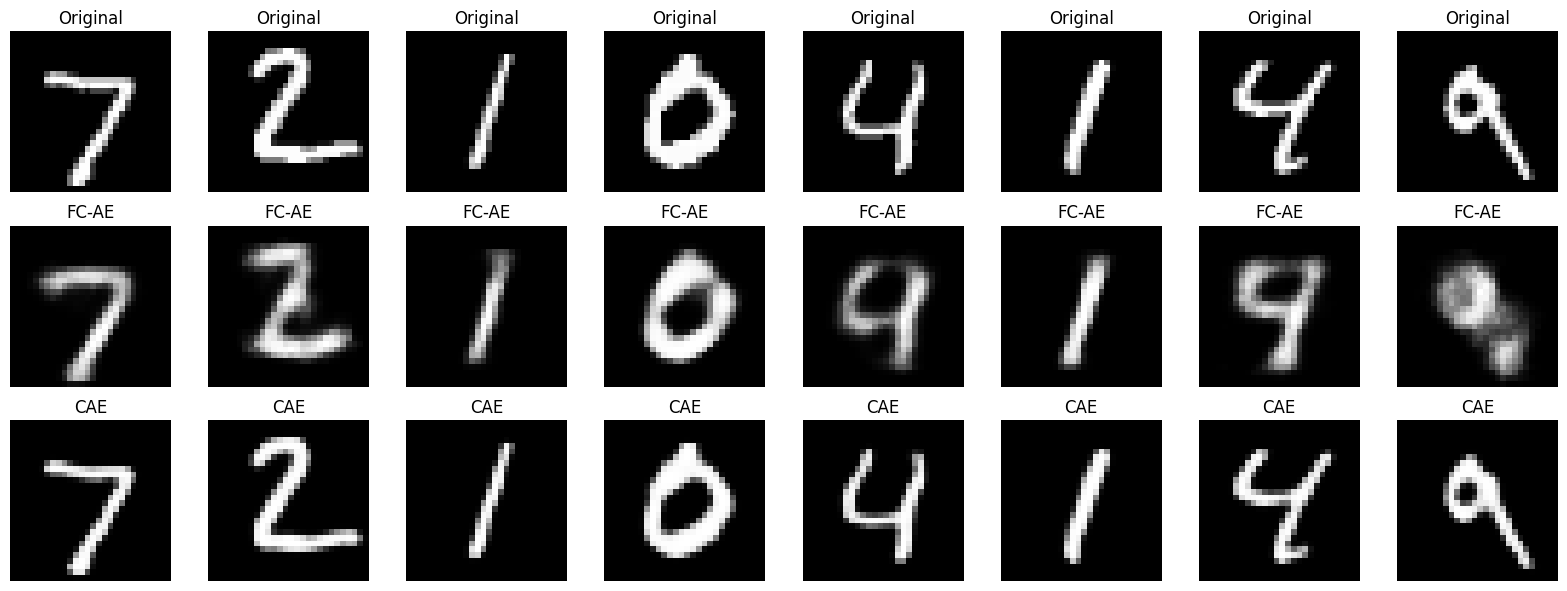

In [24]:
n = 8
recon_fc_vis = fc_ae.predict(x_test_flat[:n]).reshape(-1, 28, 28)
recon_cae_vis = cae.predict(x_test[:n]).squeeze()

plt.figure(figsize=(16, 6))
for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')
    
    # FC-AE
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(recon_fc_vis[i], cmap='gray')
    plt.title("FC-AE")
    plt.axis('off')
    
    # CAE
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(recon_cae_vis[i], cmap='gray')
    plt.title("CAE")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [25]:
def add_gaussian_noise(images, sigma=0.2):
    noise = np.random.normal(0, sigma, images.shape)
    noisy = images + noise
    return np.clip(noisy, 0., 1.)

In [26]:
def add_salt_pepper_noise(images, p=0.1):
    noisy = images.copy()
    n_pixels = images.shape[0] * images.shape[1] * images.shape[2]
    
    # Salt
    n_salt = int(n_pixels * p / 2)
    coords = [np.random.randint(0, i, n_salt) for i in images.shape[:3]]
    noisy[coords[0], coords[1], coords[2], 0] = 1.0
    
    # Pepper
    n_pepper = int(n_pixels * p / 2)
    coords = [np.random.randint(0, i, n_pepper) for i in images.shape[:3]]
    noisy[coords[0], coords[1], coords[2], 0] = 0.0
    
    return noisy

In [27]:
sigma = 0.2
x_train_noisy = add_gaussian_noise(x_train, sigma=sigma)
x_test_noisy  = add_gaussian_noise(x_test,  sigma=sigma)

print("Noisy train range:", x_train_noisy.min(), "→", x_train_noisy.max())

Noisy train range: 0.0 → 1.0


In [28]:
inp = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(32, 3, activation='relu', padding='same')(inp)
x = MaxPooling2D(2, padding='same')(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
x = MaxPooling2D(2, padding='same')(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)

# Decoder
x = UpSampling2D(2)(x)
x = Conv2D(32, 3, activation='relu', padding='same')(x)
x = UpSampling2D(2)(x)
out = Conv2D(1, 3, activation='sigmoid', padding='same')(x)

denoising_cae = Model(inp, out, name='Denoising_CAE')
denoising_cae.summary()

Model: "Denoising_CAE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
denoising_cae.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy'
)

In [30]:
history_denoise = denoising_cae.fit(
    x_train_noisy, x_train,          # noisy input → clean target
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    shuffle=True,
    verbose=1
)

Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 16s 193ms/step - loss: 0.2797 - val_loss: 0.1323
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 191ms/step - loss: 0.1097 - val_loss: 0.1011
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 190ms/step - loss: 0.0942 - val_loss: 0.0933
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 191ms/step - loss: 0.0891 - val_loss: 0.0892
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 196ms/step - loss: 0.0858 - val_loss: 0.0862
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 193ms/step - loss: 0.0834 - val_loss: 0.0842
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 194ms/step - loss: 0.0823 - val_loss: 0.0831
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 15s 204ms/step - loss: 0.0808 - val_loss: 0.0818
Epoch 9/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 200ms/step - loss: 0.0799 - val_loss: 0.0811
Epoch 10/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 15s 206ms/step - loss: 0.0794 - val_loss: 0.0802
Epoch 11/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 200ms/step - loss: 0.0783 - val_loss: 0.0802
Epoch 12/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 14

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


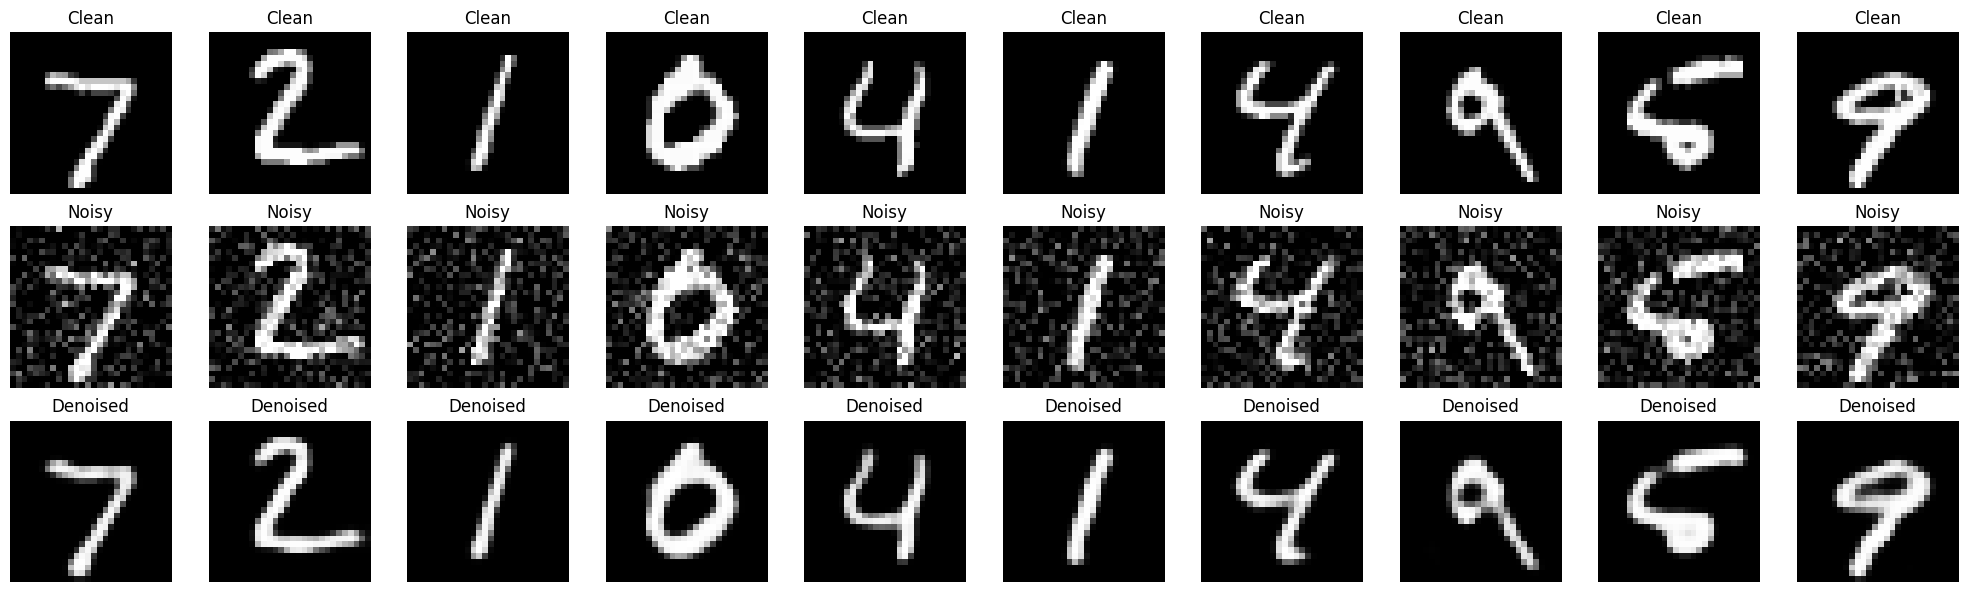

In [32]:
n = 10
denoised = denoising_cae.predict(x_test_noisy[:n])

plt.figure(figsize=(20, 6))
for i in range(n):
    # Clean
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.title("Clean")
    plt.axis('off')
    
    # Noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')
    
    # Denoised
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(denoised[i].squeeze(), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [33]:
sigmas = [0.1, 0.2, 0.3]
denoise_results = {}

for s in sigmas:
    print(f"\n=== Evaluating σ = {s} ===")
    noisy_test = add_gaussian_noise(x_test, sigma=s)
    recon = denoising_cae.predict(noisy_test)
    
    mse = mean_squared_error(x_test.reshape(len(x_test), -1),
                             recon.reshape(len(recon), -1))
    mae = mean_absolute_error(x_test.reshape(len(x_test), -1),
                              recon.reshape(len(recon), -1))
    ssim_val = np.mean([
        ssim(x_test[i].squeeze(), recon[i].squeeze(), data_range=1.0)
        for i in range(len(x_test))
    ])
    
    denoise_results[s] = {'MSE': mse, 'MAE': mae, 'SSIM': ssim_val}
    print(f"MSE: {mse:.6f} | MAE: {mae:.6f} | SSIM: {ssim_val:.4f}")


=== Evaluating σ = 0.1 ===
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
MSE: 0.003717 | MAE: 0.017924 | SSIM: 0.9554

=== Evaluating σ = 0.2 ===
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
MSE: 0.004819 | MAE: 0.021527 | SSIM: 0.9422

=== Evaluating σ = 0.3 ===
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
MSE: 0.007429 | MAE: 0.029258 | SSIM: 0.8826


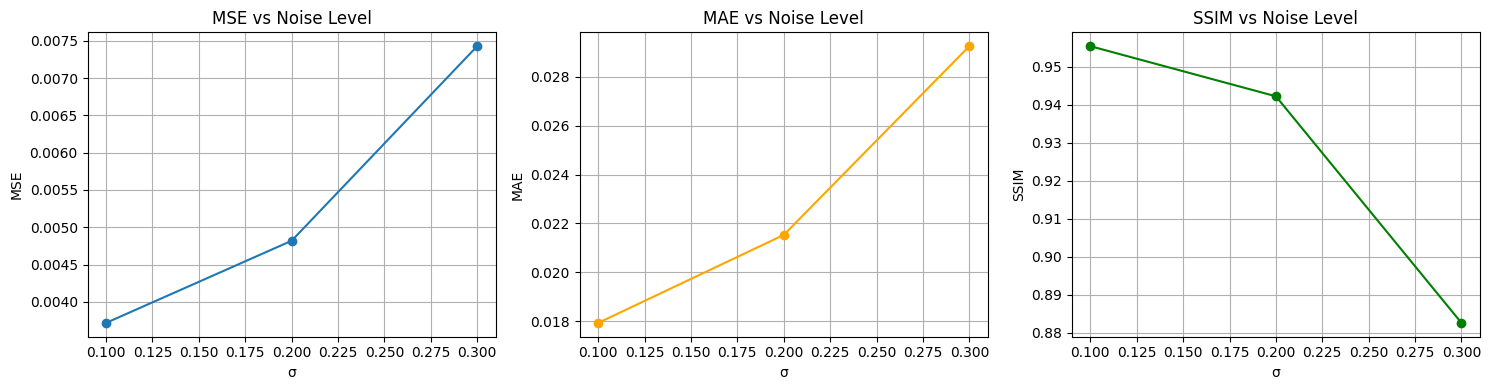

In [34]:
sigmas = list(denoise_results.keys())
mses  = [denoise_results[s]['MSE'] for s in sigmas]
maes  = [denoise_results[s]['MAE'] for s in sigmas]
ssims = [denoise_results[s]['SSIM'] for s in sigmas]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(sigmas, mses, marker='o')
axes[0].set_title('MSE vs Noise Level')
axes[0].set_xlabel('σ')
axes[0].set_ylabel('MSE')
axes[0].grid(True)

axes[1].plot(sigmas, maes, marker='o', color='orange')
axes[1].set_title('MAE vs Noise Level')
axes[1].set_xlabel('σ')
axes[1].set_ylabel('MAE')
axes[1].grid(True)

axes[2].plot(sigmas, ssims, marker='o', color='green')
axes[2].set_title('SSIM vs Noise Level')
axes[2].set_xlabel('σ')
axes[2].set_ylabel('SSIM')
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [35]:
df_noise = pd.DataFrame({
    'Noise Level (σ)': sigmas,
    'MSE': [denoise_results[s]['MSE'] for s in sigmas],
    'MAE': [denoise_results[s]['MAE'] for s in sigmas],
    'SSIM': [denoise_results[s]['SSIM'] for s in sigmas]
})
print(df_noise.to_string(index=False))

 Noise Level (σ)      MSE      MAE     SSIM
             0.1 0.003717 0.017924 0.955355
             0.2 0.004819 0.021527 0.942176
             0.3 0.007429 0.029258 0.882602


In [37]:
# Evaluate the already-trained model on salt-and-pepper noise
p_levels = [0.05, 0.10, 0.20]
sp_results = {}

for p in p_levels:
    noisy_sp = add_salt_pepper_noise(x_test, p=p)
    recon_sp = denoising_cae.predict(noisy_sp)
    
    mse = mean_squared_error(x_test.reshape(len(x_test), -1),
                             recon_sp.reshape(len(recon_sp), -1))
    ssim_val = np.mean([
        ssim(x_test[i].squeeze(), recon_sp[i].squeeze(), data_range=1.0)
        for i in range(len(x_test))
    ])
    sp_results[p] = {'MSE': mse, 'SSIM': ssim_val}
    print(f"p={p:.2f} → MSE: {mse:.6f} | SSIM: {ssim_val:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
p=0.05 → MSE: 0.005300 | SSIM: 0.9279
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
p=0.10 → MSE: 0.007689 | SSIM: 0.8842
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
p=0.20 → MSE: 0.013847 | SSIM: 0.7785


In [38]:
(_, y_train_full), (_, y_test_full) = mnist.load_data()
y_train = y_train_full[:10000]
y_test  = y_test_full[:2000]

print("Train labels shape:", y_train.shape)
print("Test labels shape :", y_test.shape)

Train labels shape: (10000,)
Test labels shape : (2000,)


In [39]:
from tensorflow.keras.layers import Layer
import tensorflow as tf

class Sampling(Layer):
    """Uses (z_mean, z_log_var) to sample z = mean + exp(0.5 * log_var) * epsilon"""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [40]:
from tensorflow.keras.layers import Flatten, Dense, Reshape, Conv2DTranspose

latent_dim = 2

encoder_inputs = Input(shape=(28, 28, 1), name='encoder_input')
x = Conv2D(32, 3, activation='relu', strides=2, padding='same')(encoder_inputs)
x = Conv2D(64, 3, activation='relu', strides=2, padding='same')(x)
x = Flatten()(x)
x = Dense(16, activation='relu')(x)

z_mean = Dense(latent_dim, name='z_mean')(x)
z_log_var = Dense(latent_dim, name='z_log_var')(x)
z = Sampling()([z_mean, z_log_var])

encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 14, 14,    │        320 │ encoder_input[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 7, 7, 64)  │     18,496 │ conv2d_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ conv2d_11[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_34 (Dense)    │ (None, 16)        │     50,192 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense_34[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense_34[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
latent_inputs = Input(shape=(latent_dim,), name='z_sampling')
x = Dense(7 * 7 * 64, activation='relu')(latent_inputs)
x = Reshape((7, 7, 64))(x)
x = Conv2DTranspose(64, 3, activation='relu', strides=2, padding='same')(x)
x = Conv2DTranspose(32, 3, activation='relu', strides=2, padding='same')(x)
decoder_outputs = Conv2DTranspose(1, 3, activation='sigmoid', padding='same')(x)

decoder = Model(latent_inputs, decoder_outputs, name='decoder')
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ z_sampling (InputLayer)         │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def call(self, inputs):
        """Required by Keras for validation / prediction"""
        z_mean, z_log_var, z = self.encoder(inputs)
        return self.decoder(z)

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            # Reconstruction loss
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2)
                )
            )

            # KL Divergence
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        """Needed for clean validation metrics"""
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)

        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                tf.keras.losses.binary_crossentropy(data, reconstruction),
                axis=(1, 2)
            )
        )
        kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
        total_loss = reconstruction_loss + kl_loss

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }


# Recreate the model
vae = VAE(encoder, decoder)
vae.compile(optimizer=Adam(learning_rate=1e-3))

In [47]:
history_vae = vae.fit(
    x_train,
    epochs=30,                # slightly more epochs for VAE
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - kl_loss: 3.4923 - loss: 198.3147 - reconstruction_loss: 194.8224 - val_kl_loss: 4.2588 - val_loss: 197.5638 - val_reconstruction_loss: 193.3050
Epoch 2/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - kl_loss: 5.1229 - loss: 189.7627 - reconstruction_loss: 184.6398 - val_kl_loss: 4.9215 - val_loss: 187.8330 - val_reconstruction_loss: 182.9115
Epoch 3/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - kl_loss: 5.9552 - loss: 182.3705 - reconstruction_loss: 176.4153 - val_kl_loss: 5.9416 - val_loss: 181.2879 - val_reconstruction_loss: 175.3463
Epoch 4/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - kl_loss: 6.0556 - loss: 177.0845 - reconstruction_loss: 171.0290 - val_kl_loss: 5.7188 - val_loss: 177.2311 - val_reconstruction_loss: 171.5123
Epoch 5/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - kl_loss: 6.0285 - loss: 173.2929 - reconstruction_loss: 167.2643 - val_kl_loss: 5.7729 - val_loss: 174.6102 - val_reconstruction_loss: 168.8372
Epoch 6/30
71

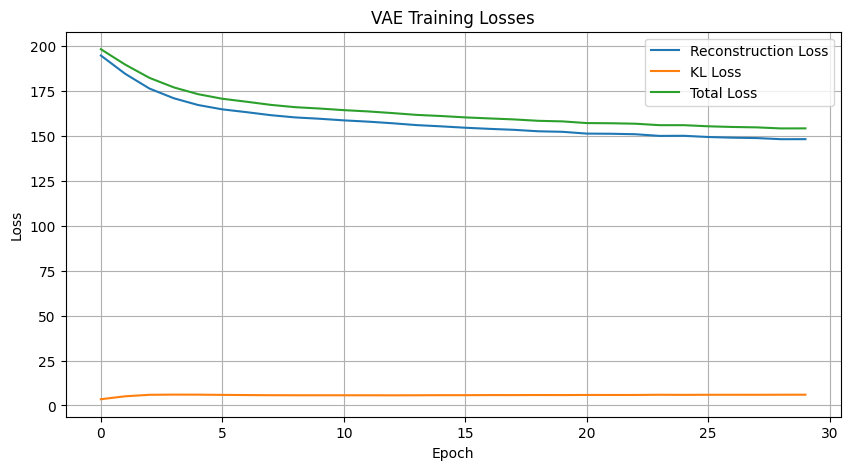

In [48]:
plt.figure(figsize=(10, 5))
plt.plot(history_vae.history['reconstruction_loss'], label='Reconstruction Loss')
plt.plot(history_vae.history['kl_loss'], label='KL Loss')
plt.plot(history_vae.history['loss'], label='Total Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VAE Training Losses')
plt.legend()
plt.grid(True)
plt.show()

In [49]:
# Encode & decode test images
z_mean_test, _, _ = encoder.predict(x_test)
recon_vae = decoder.predict(z_mean_test)

# Metrics
mse_vae = mean_squared_error(x_test.reshape(len(x_test), -1),
                             recon_vae.reshape(len(recon_vae), -1))
mae_vae = mean_absolute_error(x_test.reshape(len(x_test), -1),
                              recon_vae.reshape(len(recon_vae), -1))
ssim_vae = np.mean([
    ssim(x_test[i].squeeze(), recon_vae[i].squeeze(), data_range=1.0)
    for i in range(len(x_test))
])

print(f"Test MSE  : {mse_vae:.6f}")
print(f"Test MAE  : {mae_vae:.6f}")
print(f"Mean SSIM : {ssim_vae:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Test MSE  : 0.045224
Test MAE  : 0.106001
Mean SSIM : 0.4730


In [50]:
# Approximate final losses from last epoch
final_recon = history_vae.history['reconstruction_loss'][-1]
final_kl    = history_vae.history['kl_loss'][-1]
final_total = history_vae.history['loss'][-1]

vae_metrics = pd.DataFrame({
    'Metric': ['Reconstruction Loss', 'KL Loss', 'Total Loss',
               'Test MSE', 'Test MAE', 'Mean SSIM'],
    'Value': [final_recon, final_kl, final_total,
              mse_vae, mae_vae, ssim_vae]
})
print(vae_metrics.to_string(index=False))

             Metric      Value
Reconstruction Loss 148.252441
            KL Loss   6.003921
         Total Loss 154.256363
           Test MSE   0.045224
           Test MAE   0.106001
          Mean SSIM   0.472997


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


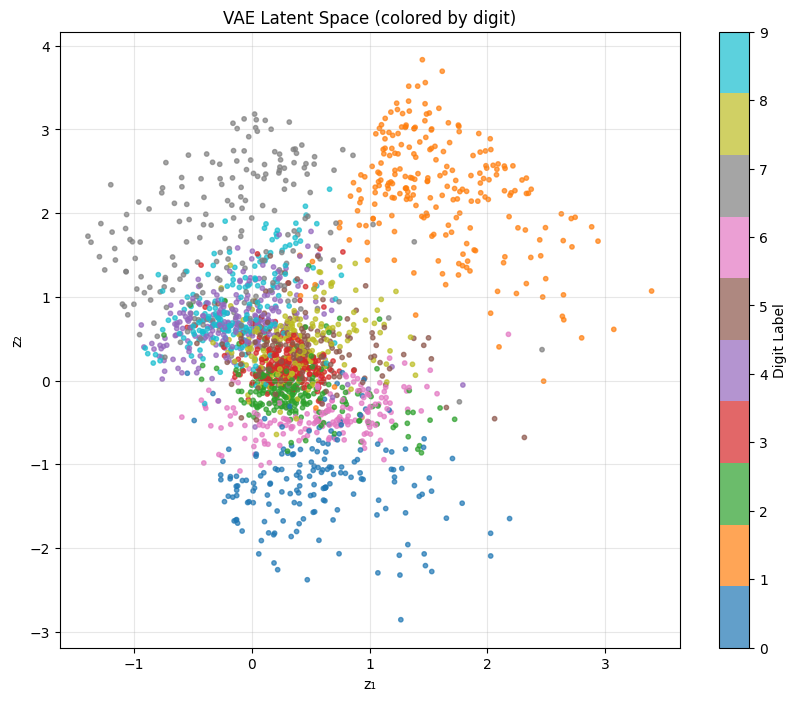

In [51]:
z_mean, _, _ = encoder.predict(x_test)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(z_mean[:, 0], z_mean[:, 1], c=y_test, cmap='tab10', alpha=0.7, s=10)
plt.colorbar(scatter, label='Digit Label')
plt.xlabel('z₁')
plt.ylabel('z₂')
plt.title('VAE Latent Space (colored by digit)')
plt.grid(True, alpha=0.3)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


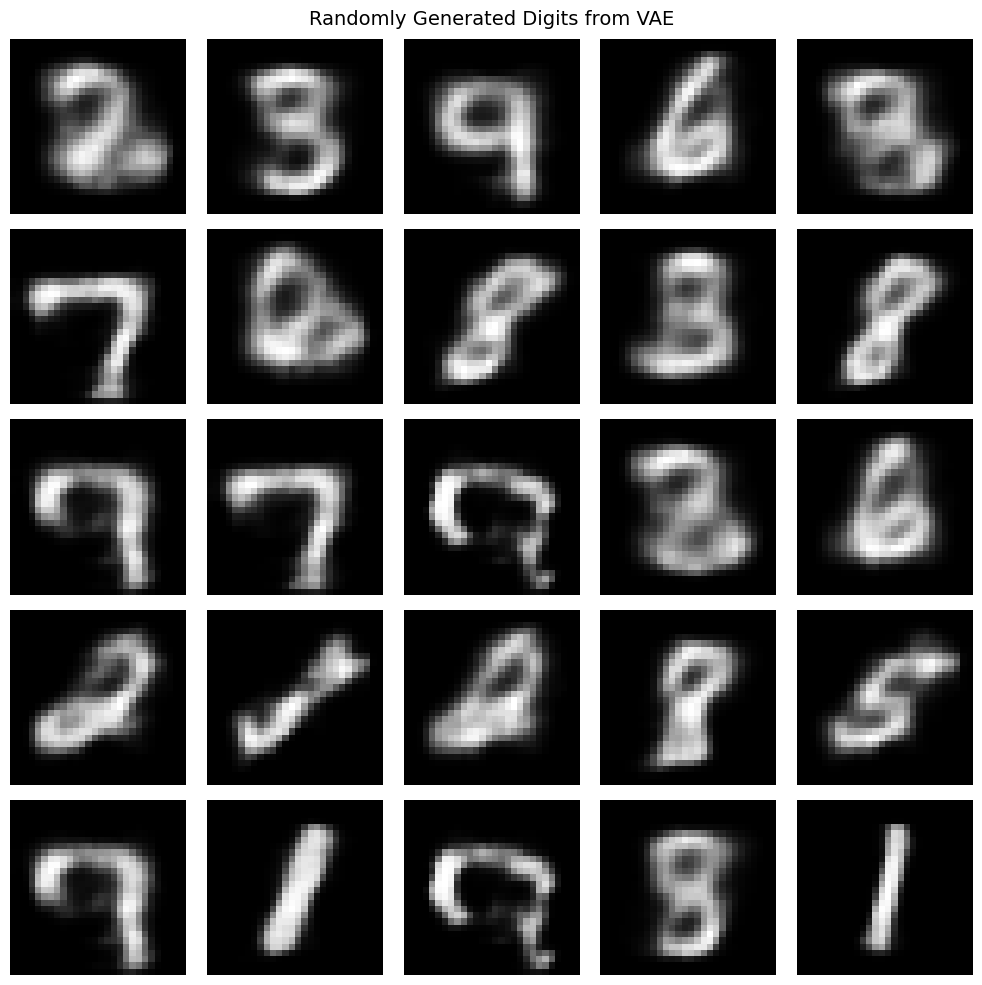

In [52]:
n_samples = 25
random_z = np.random.normal(size=(n_samples, latent_dim))
generated = decoder.predict(random_z)

plt.figure(figsize=(10, 10))
for i in range(n_samples):
    ax = plt.subplot(5, 5, i + 1)
    plt.imshow(generated[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.suptitle('Randomly Generated Digits from VAE', fontsize=14)
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


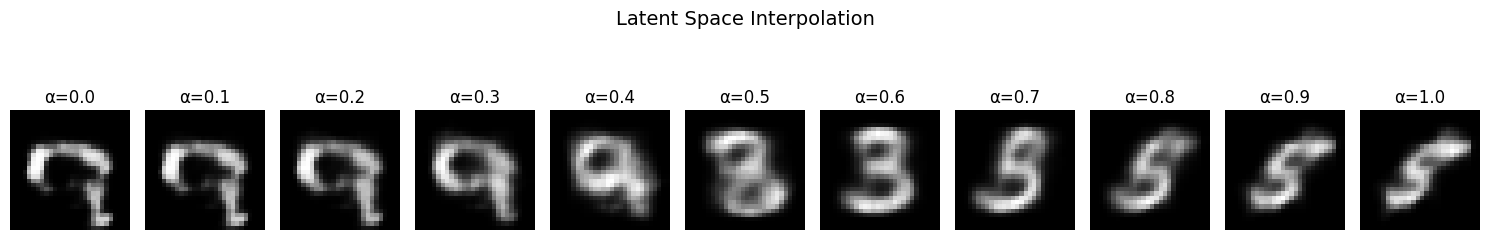

In [53]:
# Select two points in latent space
z_A = np.array([[-2.0, 0.0]])   # example point
z_B = np.array([[ 2.0, 0.0]])   # example point

alphas = np.linspace(0, 1, 11)
interpolated = []

for alpha in alphas:
    z = (1 - alpha) * z_A + alpha * z_B
    img = decoder.predict(z)
    interpolated.append(img[0])

plt.figure(figsize=(15, 3))
for i, img in enumerate(interpolated):
    ax = plt.subplot(1, 11, i + 1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f'α={alphas[i]:.1f}')
    plt.axis('off')
plt.suptitle('Latent Space Interpolation', fontsize=14)
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


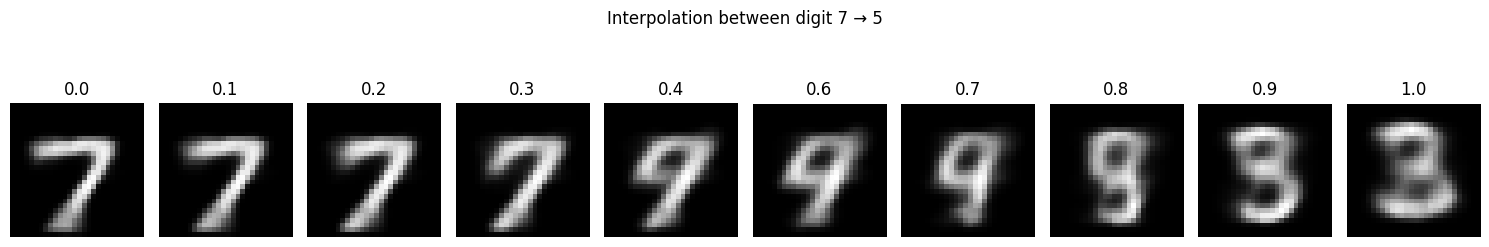

In [54]:
# Pick two real test images of different digits and interpolate between their encodings
idx1, idx2 = 0, 15          # change these indices if you want
z1, _, _ = encoder.predict(x_test[idx1:idx1+1])
z2, _, _ = encoder.predict(x_test[idx2:idx2+1])

alphas = np.linspace(0, 1, 10)
plt.figure(figsize=(15, 3))
for i, alpha in enumerate(alphas):
    z = (1 - alpha) * z1 + alpha * z2
    img = decoder.predict(z)
    ax = plt.subplot(1, 10, i + 1)
    plt.imshow(img[0].squeeze(), cmap='gray')
    plt.title(f'{alpha:.1f}')
    plt.axis('off')
plt.suptitle(f'Interpolation between digit {y_test[idx1]} → {y_test[idx2]}')
plt.tight_layout()
plt.show()

In [55]:
# Make sure these variables exist from previous phases
# If any is missing, re-run the corresponding metric cell

results = {
    'FC Autoencoder': {
        'MSE': mse_fc,
        'MAE': mae_fc,
        'SSIM': mean_ssim_fc,
        'Parameters': fc_ae.count_params(),
        'Time (approx)': '—'          # fill manually if you timed it
    },
    'Convolutional AE': {
        'MSE': mse_cae,
        'MAE': mae_cae,
        'SSIM': mean_ssim_cae,
        'Parameters': cae.count_params(),
        'Time (approx)': '—'
    },
    'Denoising CAE': {
        'MSE': denoise_results[0.2]['MSE'],   # using σ=0.2 as main result
        'MAE': denoise_results[0.2]['MAE'],
        'SSIM': denoise_results[0.2]['SSIM'],
        'Parameters': denoising_cae.count_params(),
        'Time (approx)': '—'
    },
    'VAE': {
        'MSE': mse_vae,
        'MAE': mae_vae,
        'SSIM': ssim_vae,
        'Parameters': encoder.count_params() + decoder.count_params(),
        'Time (approx)': '—'
    }
}

In [56]:
df_consolidated = pd.DataFrame(results).T
df_consolidated = df_consolidated[['MSE', 'MAE', 'SSIM', 'Parameters', 'Time (approx)']]
print("=== Consolidated Results ===")
print(df_consolidated.to_string())

=== Consolidated Results ===
                       MSE       MAE      SSIM Parameters Time (approx)
FC Autoencoder    0.023641  0.061607  0.720087     211040             —
Convolutional AE  0.001926  0.012844  0.981171      74497             —
Denoising CAE     0.004819  0.021527  0.942176      74497             —
VAE               0.045224  0.106001  0.472997     134165             —


In [57]:
df_recon = pd.DataFrame({
    'Model': ['Fully Connected AE', 'Convolutional AE', 'Denoising CAE'],
    'MSE': [mse_fc, mse_cae, denoise_results[0.2]['MSE']],
    'MAE': [mae_fc, mae_cae, denoise_results[0.2]['MAE']],
    'SSIM': [mean_ssim_fc, mean_ssim_cae, denoise_results[0.2]['SSIM']],
    'Parameters': [fc_ae.count_params(), cae.count_params(), denoising_cae.count_params()]
})
print("=== Reconstruction Comparison (Deterministic Models) ===")
print(df_recon.to_string(index=False))

=== Reconstruction Comparison (Deterministic Models) ===
             Model      MSE      MAE     SSIM  Parameters
Fully Connected AE 0.023641 0.061607 0.720087      211040
  Convolutional AE 0.001926 0.012844 0.981171       74497
     Denoising CAE 0.004819 0.021527 0.942176       74497


In [58]:
print("=== VAE Metrics ===")
print(vae_metrics.to_string(index=False))

=== VAE Metrics ===
             Metric      Value
Reconstruction Loss 148.252441
            KL Loss   6.003921
         Total Loss 154.256363
           Test MSE   0.045224
           Test MAE   0.106001
          Mean SSIM   0.472997


In [59]:
# Using Fully Connected AE reconstructions (you can change to any model)
recon_for_error = fc_ae.predict(x_test_flat)

# Per-image MSE
per_image_error = np.mean((x_test_flat - recon_for_error)**2, axis=1)

print("Error statistics:")
print(f"Min  : {per_image_error.min():.6f}")
print(f"Max  : {per_image_error.max():.6f}")
print(f"Mean : {per_image_error.mean():.6f}")
print(f"Std  : {per_image_error.std():.6f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Error statistics:
Min  : 0.001980
Max  : 0.070505
Mean : 0.023641
Std  : 0.011912


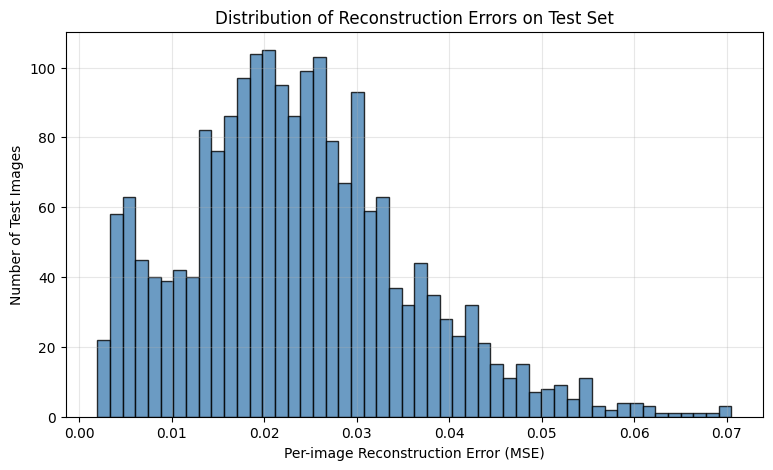

In [60]:
plt.figure(figsize=(9, 5))
plt.hist(per_image_error, bins=50, color='steelblue', edgecolor='black', alpha=0.8)
plt.xlabel('Per-image Reconstruction Error (MSE)')
plt.ylabel('Number of Test Images')
plt.title('Distribution of Reconstruction Errors on Test Set')
plt.grid(True, alpha=0.3)
plt.show()

In [61]:
# Get indices of the 5 worst reconstructions
worst_indices = np.argsort(per_image_error)[-5:][::-1]   # descending order

print("Top 5 highest reconstruction errors:")
for rank, idx in enumerate(worst_indices, 1):
    print(f"{rank}. Index {idx} | Error = {per_image_error[idx]:.6f} | True digit = {y_test[idx]}")

Top 5 highest reconstruction errors:
1. Index 1070 | Error = 0.070505 | True digit = 5
2. Index 514 | Error = 0.069425 | True digit = 6
3. Index 654 | Error = 0.069404 | True digit = 5
4. Index 1170 | Error = 0.068134 | True digit = 8
5. Index 1782 | Error = 0.066978 | True digit = 8


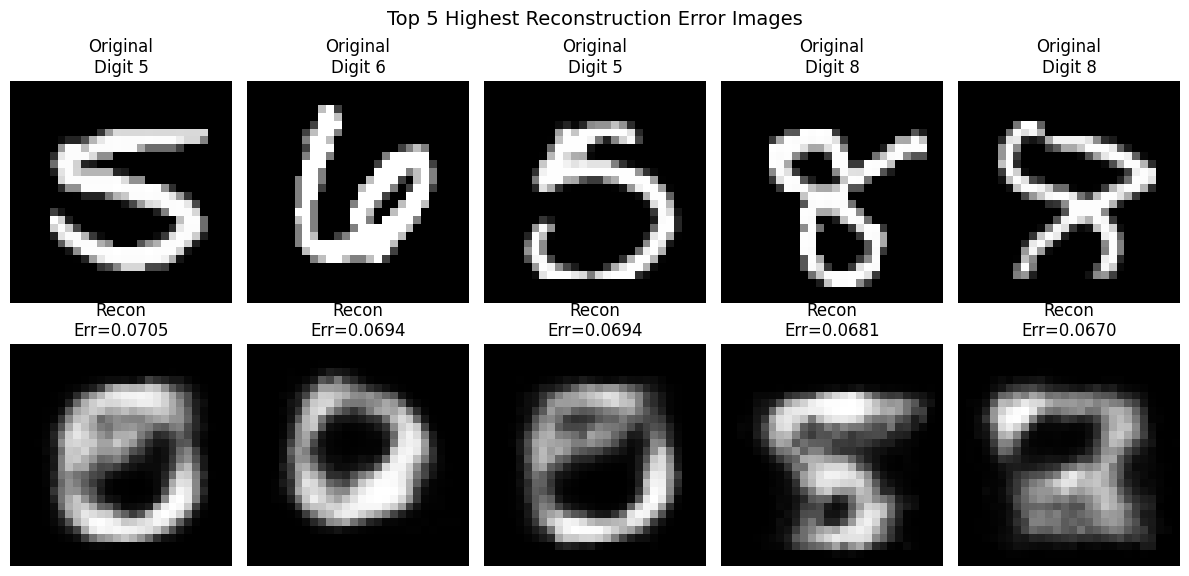

In [62]:
plt.figure(figsize=(12, 6))
for i, idx in enumerate(worst_indices):
    # Original
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx].squeeze(), cmap='gray')
    plt.title(f"Original\nDigit {y_test[idx]}")
    plt.axis('off')
    
    # Reconstruction
    ax = plt.subplot(2, 5, i + 6)
    plt.imshow(recon_for_error[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Recon\nErr={per_image_error[idx]:.4f}")
    plt.axis('off')

plt.suptitle('Top 5 Highest Reconstruction Error Images', fontsize=14)
plt.tight_layout()
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


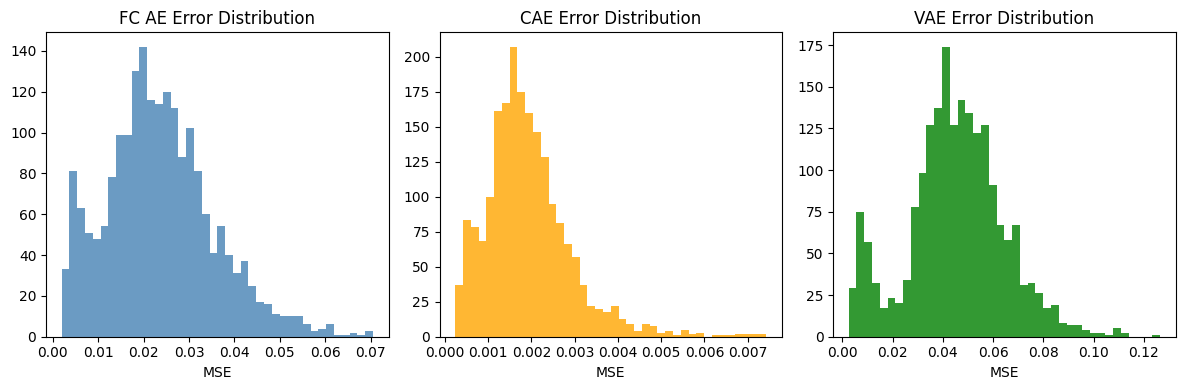

In [63]:
# CAE errors
recon_cae_flat = cae.predict(x_test).reshape(len(x_test), -1)
error_cae = np.mean((x_test.reshape(len(x_test), -1) - recon_cae_flat)**2, axis=1)

# VAE errors
error_vae = np.mean((x_test.reshape(len(x_test), -1) - recon_vae.reshape(len(recon_vae), -1))**2, axis=1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(per_image_error, bins=40, color='steelblue', alpha=0.8)
plt.title('FC AE Error Distribution')
plt.xlabel('MSE')

plt.subplot(1, 3, 2)
plt.hist(error_cae, bins=40, color='orange', alpha=0.8)
plt.title('CAE Error Distribution')
plt.xlabel('MSE')

plt.subplot(1, 3, 3)
plt.hist(error_vae, bins=40, color='green', alpha=0.8)
plt.title('VAE Error Distribution')
plt.xlabel('MSE')

plt.tight_layout()
plt.show()

In [64]:
print("="*60)
print("PHASE 5 COMPLETE – KEY NUMBERS FOR REPORT")
print("="*60)
print("\n1. Consolidated Results Table:")
print(df_consolidated)
print("\n2. Reconstruction Comparison (Deterministic Models):")
print(df_recon)
print("\n3. VAE Metrics:")
print(vae_metrics)
print("\n4. Reconstruction Error Statistics (FC AE):")
print(f"   Typical range : {per_image_error.min():.5f} – {per_image_error.max():.5f}")
print(f"   Mean error    : {per_image_error.mean():.5f}")
print(f"   Std deviation : {per_image_error.std():.5f}")
print("\n5. Top-5 High-Error Image Indices:", worst_indices.tolist())

PHASE 5 COMPLETE – KEY NUMBERS FOR REPORT

1. Consolidated Results Table:
                       MSE       MAE      SSIM Parameters Time (approx)
FC Autoencoder    0.023641  0.061607  0.720087     211040             —
Convolutional AE  0.001926  0.012844  0.981171      74497             —
Denoising CAE     0.004819  0.021527  0.942176      74497             —
VAE               0.045224  0.106001  0.472997     134165             —

2. Reconstruction Comparison (Deterministic Models):
                Model       MSE       MAE      SSIM  Parameters
0  Fully Connected AE  0.023641  0.061607  0.720087      211040
1    Convolutional AE  0.001926  0.012844  0.981171       74497
2       Denoising CAE  0.004819  0.021527  0.942176       74497

3. VAE Metrics:
                Metric       Value
0  Reconstruction Loss  148.252441
1              KL Loss    6.003921
2           Total Loss  154.256363
3             Test MSE    0.045224
4             Test MAE    0.106001
5            Mean SSIM    0.4

In [65]:
from tensorflow.keras.layers import Conv2DTranspose

def build_cae_transpose():
    inp = Input(shape=(28, 28, 1))

    # Encoder (same as before)
    x = Conv2D(32, 3, activation='relu', padding='same')(inp)
    x = MaxPooling2D(2, padding='same')(x)
    x = Conv2D(64, 3, activation='relu', padding='same')(x)
    x = MaxPooling2D(2, padding='same')(x)
    x = Conv2D(64, 3, activation='relu', padding='same')(x)

    # Decoder using Conv2DTranspose instead of UpSampling2D
    x = Conv2DTranspose(64, 3, strides=2, activation='relu', padding='same')(x)
    x = Conv2DTranspose(32, 3, strides=2, activation='relu', padding='same')(x)
    out = Conv2D(1, 3, activation='sigmoid', padding='same')(x)

    model = Model(inp, out, name='CAE_Transpose')
    model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy')
    return model

cae_transpose = build_cae_transpose()
cae_transpose.summary()

Model: "CAE_Transpose"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,425 (435.25 KB)

 Trainable params: 111,425 (435.25 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
history_transpose = cae_transpose.fit(
    x_train, x_train,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 17s 197ms/step - loss: 0.3256 - val_loss: 0.1352
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 192ms/step - loss: 0.1013 - val_loss: 0.0894
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 197ms/step - loss: 0.0831 - val_loss: 0.0821
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 193ms/step - loss: 0.0781 - val_loss: 0.0794
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 191ms/step - loss: 0.0761 - val_loss: 0.0764
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 191ms/step - loss: 0.0741 - val_loss: 0.0753
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 191ms/step - loss: 0.0730 - val_loss: 0.0739
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 191ms/step - loss: 0.0722 - val_loss: 0.0731
Epoch 9/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 13s 189ms/step - loss: 0.0714 - val_loss: 0.0723
Epoch 10/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 13s 189ms/step - loss: 0.0706 - val_loss: 0.0719
Epoch 11/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 191ms/step - loss: 0.0701 - val_loss: 0.0712
Epoch 12/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 14

In [67]:
recon_transpose = cae_transpose.predict(x_test)

mse_trans = mean_squared_error(x_test.reshape(len(x_test), -1),
                               recon_transpose.reshape(len(recon_transpose), -1))
mae_trans = mean_absolute_error(x_test.reshape(len(x_test), -1),
                                recon_transpose.reshape(len(recon_transpose), -1))
ssim_trans = np.mean([
    ssim(x_test[i].squeeze(), recon_transpose[i].squeeze(), data_range=1.0)
    for i in range(len(x_test))
])

print("=== Comparison: UpSampling2D vs Conv2DTranspose ===")
print(f"{'Model':<25} {'MSE':>10} {'MAE':>10} {'SSIM':>10} {'Params':>10}")
print(f"{'CAE (UpSampling2D)':<25} {mse_cae:10.6f} {mae_cae:10.6f} {mean_ssim_cae:10.4f} {cae.count_params():10}")
print(f"{'CAE (Conv2DTranspose)':<25} {mse_trans:10.6f} {mae_trans:10.6f} {ssim_trans:10.4f} {cae_transpose.count_params():10}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
=== Comparison: UpSampling2D vs Conv2DTranspose ===
Model                            MSE        MAE       SSIM     Params
CAE (UpSampling2D)          0.001926   0.012844     0.9812      74497
CAE (Conv2DTranspose)       0.002297   0.014104     0.9758     111425


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


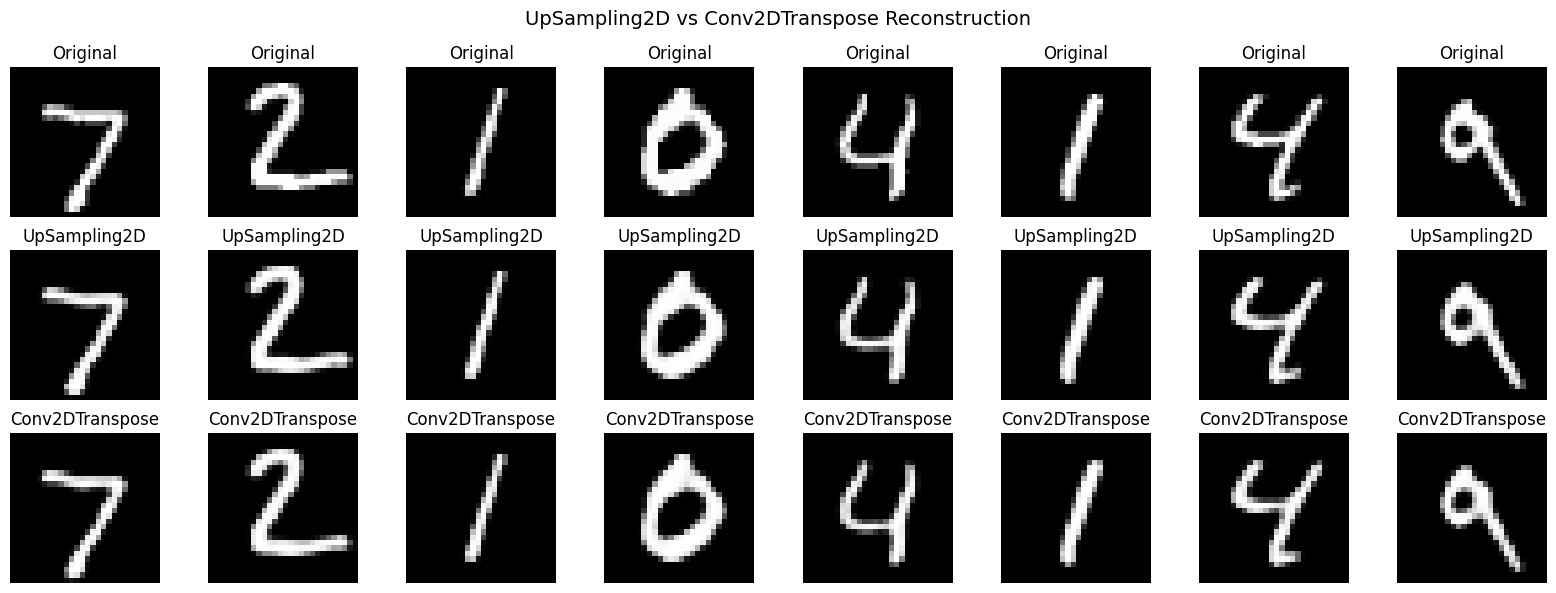

In [68]:
n = 8
plt.figure(figsize=(16, 6))
for i in range(n):
    # Original
    ax = plt.subplot(3, n, i+1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Original CAE (UpSampling)
    ax = plt.subplot(3, n, i+1+n)
    plt.imshow(cae.predict(x_test[i:i+1])[0].squeeze(), cmap='gray')
    plt.title("UpSampling2D")
    plt.axis('off')

    # Transpose CAE
    ax = plt.subplot(3, n, i+1+2*n)
    plt.imshow(recon_transpose[i].squeeze(), cmap='gray')
    plt.title("Conv2DTranspose")
    plt.axis('off')

plt.suptitle("UpSampling2D vs Conv2DTranspose Reconstruction", fontsize=14)
plt.tight_layout()
plt.show()

In [71]:
def build_vae(latent_dim=2):
    # ----- Encoder -----
    encoder_inputs = Input(shape=(28, 28, 1))
    x = Conv2D(32, 3, activation='relu', strides=2, padding='same')(encoder_inputs)
    x = Conv2D(64, 3, activation='relu', strides=2, padding='same')(x)
    x = Flatten()(x)
    x = Dense(32, activation='relu')(x)

    z_mean = Dense(latent_dim, name='z_mean')(x)
    z_log_var = Dense(latent_dim, name='z_log_var')(x)
    z = Sampling()([z_mean, z_log_var])

    encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name=f'encoder_{latent_dim}')

    # ----- Decoder -----
    latent_inputs = Input(shape=(latent_dim,))
    x = Dense(7 * 7 * 64, activation='relu')(latent_inputs)
    x = Reshape((7, 7, 64))(x)
    x = Conv2DTranspose(64, 3, activation='relu', strides=2, padding='same')(x)
    x = Conv2DTranspose(32, 3, activation='relu', strides=2, padding='same')(x)
    decoder_outputs = Conv2DTranspose(1, 3, activation='sigmoid', padding='same')(x)

    decoder = Model(latent_inputs, decoder_outputs, name=f'decoder_{latent_dim}')

    # ----- Full VAE with call() and test_step() -----
    class VAE(Model):
        def __init__(self, encoder, decoder, **kwargs):
            super().__init__(**kwargs)
            self.encoder = encoder
            self.decoder = decoder
            self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
            self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
            self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

        @property
        def metrics(self):
            return [
                self.total_loss_tracker,
                self.reconstruction_loss_tracker,
                self.kl_loss_tracker,
            ]

        def call(self, inputs):
            z_mean, z_log_var, z = self.encoder(inputs)
            return self.decoder(z)

        def train_step(self, data):
            with tf.GradientTape() as tape:
                z_mean, z_log_var, z = self.encoder(data)
                reconstruction = self.decoder(z)

                reconstruction_loss = tf.reduce_mean(
                    tf.reduce_sum(
                        tf.keras.losses.binary_crossentropy(data, reconstruction),
                        axis=(1, 2)
                    )
                )
                kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
                kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
                total_loss = reconstruction_loss + kl_loss

            grads = tape.gradient(total_loss, self.trainable_weights)
            self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

            self.total_loss_tracker.update_state(total_loss)
            self.reconstruction_loss_tracker.update_state(reconstruction_loss)
            self.kl_loss_tracker.update_state(kl_loss)

            return {
                "loss": self.total_loss_tracker.result(),
                "reconstruction_loss": self.reconstruction_loss_tracker.result(),
                "kl_loss": self.kl_loss_tracker.result(),
            }

        def test_step(self, data):
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2)
                )
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss

            self.total_loss_tracker.update_state(total_loss)
            self.reconstruction_loss_tracker.update_state(reconstruction_loss)
            self.kl_loss_tracker.update_state(kl_loss)

            return {
                "loss": self.total_loss_tracker.result(),
                "reconstruction_loss": self.reconstruction_loss_tracker.result(),
                "kl_loss": self.kl_loss_tracker.result(),
            }

    vae = VAE(encoder, decoder)
    vae.compile(optimizer=Adam(learning_rate=1e-3))
    return vae, encoder, decoder

In [72]:
vae_8, encoder_8, decoder_8 = build_vae(latent_dim=8)

history_vae8 = vae_8.fit(
    x_train,
    epochs=30,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - kl_loss: 2.3143 - loss: 305.2010 - reconstruction_loss: 302.8868 - val_kl_loss: 2.2921 - val_loss: 217.1669 - val_reconstruction_loss: 214.8748
Epoch 2/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - kl_loss: 2.8415 - loss: 211.3253 - reconstruction_loss: 208.4839 - val_kl_loss: 3.4279 - val_loss: 208.0726 - val_reconstruction_loss: 204.6448
Epoch 3/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - kl_loss: 3.9972 - loss: 202.9015 - reconstruction_loss: 198.9044 - val_kl_loss: 4.9265 - val_loss: 199.9531 - val_reconstruction_loss: 195.0267
Epoch 4/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - kl_loss: 6.0672 - loss: 192.9516 - reconstruction_loss: 186.8843 - val_kl_loss: 6.5687 - val_loss: 189.4983 - val_reconstruction_loss: 182.9296
Epoch 5/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - kl_loss: 7.2356 - loss: 183.5489 - reconstruction_loss: 176.3133 - val_kl_loss: 8.1578 - val_loss: 178.2621 - val_reconstruction_loss: 170.1043
Epoch 6/30
71

In [73]:
# Already have results for latent_dim=2 from earlier (mse_vae, etc.)

z_mean_8, _, _ = encoder_8.predict(x_test)
recon_vae8 = decoder_8.predict(z_mean_8)

mse_vae8 = mean_squared_error(x_test.reshape(len(x_test), -1),
                              recon_vae8.reshape(len(recon_vae8), -1))
ssim_vae8 = np.mean([
    ssim(x_test[i].squeeze(), recon_vae8[i].squeeze(), data_range=1.0)
    for i in range(len(x_test))
])

print("=== VAE Latent Dimension Comparison ===")
print(f"{'Latent Dim':<12} {'Test MSE':>12} {'Mean SSIM':>12}")
print(f"{'2':<12} {mse_vae:12.6f} {ssim_vae:12.4f}")
print(f"{'8':<12} {mse_vae8:12.6f} {ssim_vae8:12.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
=== VAE Latent Dimension Comparison ===
Latent Dim       Test MSE    Mean SSIM
2                0.045224       0.4730
8                0.028687       0.6857


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


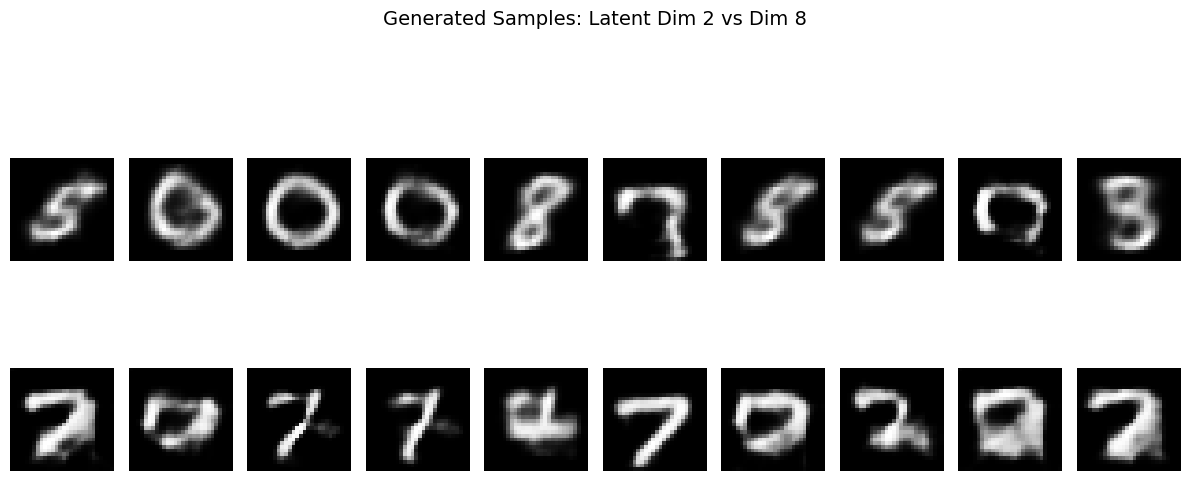

In [74]:
# Generate 25 samples from both models
z_random_2 = np.random.normal(size=(25, 2))
z_random_8 = np.random.normal(size=(25, 8))

gen_2 = decoder.predict(z_random_2)      # original decoder (dim=2)
gen_8 = decoder_8.predict(z_random_8)

plt.figure(figsize=(12, 6))
plt.suptitle("Generated Samples: Latent Dim 2 vs Dim 8", fontsize=14)

for i in range(10):
    ax = plt.subplot(2, 10, i+1)
    plt.imshow(gen_2[i].squeeze(), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.ylabel("dim=2", fontsize=12)

    ax = plt.subplot(2, 10, i+11)
    plt.imshow(gen_8[i].squeeze(), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.ylabel("dim=8", fontsize=12)

plt.tight_layout()
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


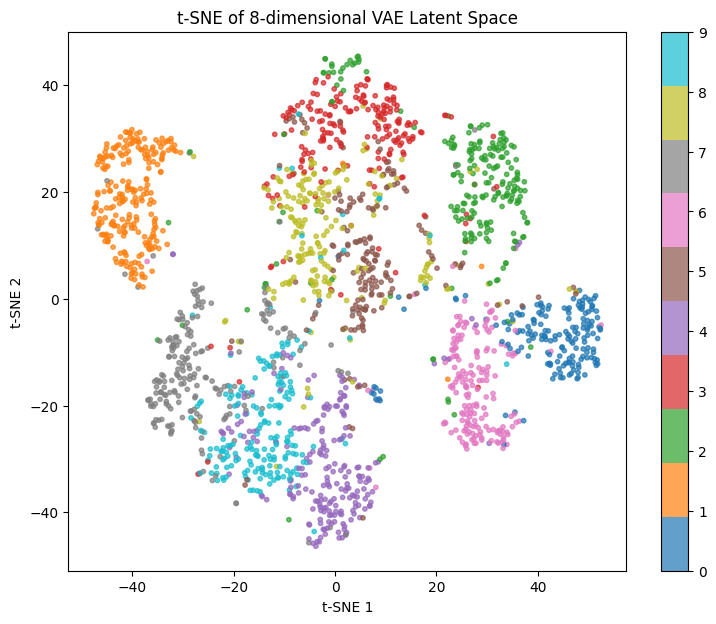

In [75]:
from sklearn.manifold import TSNE

z_mean_8, _, _ = encoder_8.predict(x_test)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
z_tsne = tsne.fit_transform(z_mean_8)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(z_tsne[:, 0], z_tsne[:, 1], c=y_test, cmap='tab10', s=10, alpha=0.7)
plt.colorbar(scatter)
plt.title("t-SNE of 8-dimensional VAE Latent Space")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()